# Dates & Times
**Topic:** Python Fundamentals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


---
## What you'll explore

By the end of this demo you will be able to:

- **Parse** date strings into Python `datetime` objects and pandas `Timestamp` values
- **Explain** how resampling aggregates a time series to a coarser time resolution
- **Interpret** datetime components (year, month, day of week) as features for machine learning models

---
## How we got here

In *05: String Methods* we cleaned text data. Dates arrive as strings too, and they require their own specialized parsing tools. In *04: Data Structures* we saw that pandas stores dates as a special dtype (`datetime64`). This notebook connects those ideas and introduces the time-series operations that are central to forecasting, anomaly detection, and financial analysis.

---
## Why this matters for data science

Time is one of the richest sources of features in machine learning. Day of week predicts retail sales; month predicts energy demand; hour of day predicts website traffic. Before you can extract any of these features, you must parse the date column correctly. Resampling is the foundation of time-series EDA: aggregating daily stock prices to monthly or weekly data before modeling is standard practice that prevents your model from overfitting to daily noise.

---
## Try it yourself

In [2]:
# ▶ Run this cell and observe the output.
# Then try changing the values and running again.

from datetime import date, datetime, timedelta

today     = date.today()
tomorrow  = today + timedelta(days=1)
last_week = today - timedelta(weeks=1)

print(f'Today:     {today}')
print(f'Tomorrow:  {tomorrow}')
print(f'Last week: {last_week}')
print(f'Day of week (Mon=0): {today.weekday()}')

Today:     2026-06-09
Tomorrow:  2026-06-10
Last week: 2026-06-02
Day of week (Mon=0): 1


In [ ]:
# ✏️ Your turn — modify this code:
# 1. Change the start date to '2020-03-15' and recalculate the duration
# 2. Format end_date as 'March 31, 2024' using strftime
# 3. What does .isoformat() return? Compare it to str(end_date).

from datetime import date

start = date(2024, 1, 1)
end   = date(2024, 3, 31)

duration = end - start
print(f'Project ran for {duration.days} days')
print(f'Formatted end: {end.strftime("%B %d, %Y")}')

In [3]:
# 🎯 Challenge:
# Calculate how many days old you are using the datetime module.
# Steps: create a date object for your birthday, subtract from today, print the days.
# Hint: date.today() gives today's date; subtracting two dates gives a timedelta object

from datetime import date

# Your code here:

---
## What's happening?

Python's `datetime` module represents a point in time as a structured object with year, month, day, hour, minute, and second attributes. Pandas wraps this in `Timestamp` and adds vectorized operations through `DatetimeIndex`.

| Operation | Python / pandas code | What it produces |
|-----------|---------------------|-----------------|
| Parse a string | `pd.to_datetime("2024-03-15")` | A `Timestamp` |
| Extract component | `ts.month`, `ts.dayofweek` | An integer (feature for ML) |
| Set index | `df.set_index("date")` | Enables time-based slicing |
| Resample | `df.resample("ME").mean()` | Aggregate to monthly means |
| Shift | `df["price"].shift(7)` | Create a 7-day lag feature |
| Rolling window | `df["price"].rolling(30).mean()` | 30-day moving average |

```python
df["date"]    = pd.to_datetime(df["date"])
df["month"]   = df["date"].dt.month
df["weekday"] = df["date"].dt.dayofweek   # 0=Monday, 6=Sunday
df["is_weekend"] = df["weekday"] >= 5
```

### `dt` accessor: the string accessor's equivalent for dates

Just as `.str.lower()` applies string methods to a Series, `.dt.month` applies datetime attribute extraction. After setting a `DatetimeIndex`, you can also slice with strings: `df["2024-01":"2024-03"]` returns all rows in those three months.

Return to the widget and switch between resampling frequencies to see how the choice changes the signal you send to a model.

---
## A direct example: parsing dates and extracting features

Six order dates stored as strings. `pd.to_datetime()` converts them into `Timestamp` values; the `.dt` accessor then extracts month and weekday as new columns.

- **Notice:** Before parsing, the date column is just text — pandas cannot group or extract components from a string
- **Notice:** After parsing, `.dt.month_name()` and `.dt.day_name()` turn each date into features a model can use directly
- **Notice:** Grouping by the extracted month column is the same idea as resampling, applied to a small DataFrame

        date     month    weekday  amount
0 2024-01-08   January     Monday     120
1 2024-02-14  February  Wednesday      85
2 2024-03-01     March     Friday     200
3 2024-03-22     March     Friday     150
4 2024-04-05     April     Friday      95
5 2024-04-19     April     Friday     175


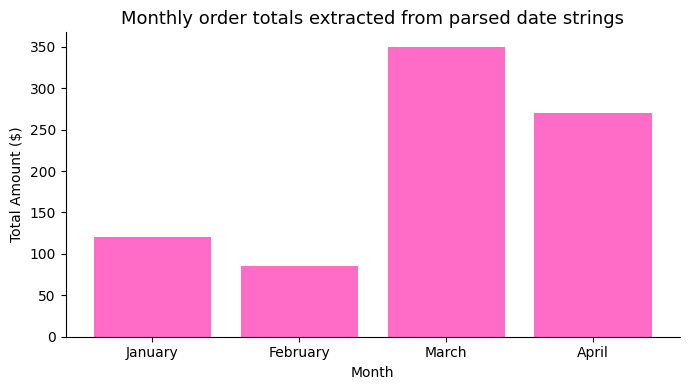

In [5]:
dates   = ["2024-01-08", "2024-02-14", "2024-03-01",
           "2024-03-22", "2024-04-05", "2024-04-19"]
amounts = [120, 85, 200, 150, 95, 175]

orders = pd.DataFrame({"date": pd.to_datetime(dates), "amount": amounts})
orders["month"]   = orders["date"].dt.month_name()
orders["weekday"] = orders["date"].dt.day_name()

print(orders[["date", "month", "weekday", "amount"]])

monthly = orders.groupby("month")["amount"].sum().reindex(
    ["January", "February", "March", "April"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(monthly.index, monthly.values, color="#FF6CC7")
ax.set_title("Monthly order totals extracted from parsed date strings", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Total Amount ($)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## Real-world example: Daily bike share ridership in Washington D.C.

The Capital Bikeshare dataset records daily rentals from 2011 to 2012. Resampling from daily to weekly and monthly shows the seasonal trend that would otherwise be obscured by day-to-day noise.

Notice:

- **Notice:** The daily series is noisy; weekend drops and Monday spikes make the seasonal trend hard to read at that granularity
- **Notice:** Monthly resampling reveals a clear seasonal pattern: ridership peaks in summer and drops in winter, which is the signal most relevant for capacity planning
- **Notice:** The monthly mean is not the same as simply taking every 30th daily value; it averages all observations in each calendar month, which is what `.resample("ME").mean()` computes

> **Discussion question:** A model trained on monthly averages to predict next month's ridership ignores the day-of-week pattern. A model trained on daily data can capture that pattern but has far more rows. How would you decide which granularity to train on for a given forecasting goal?

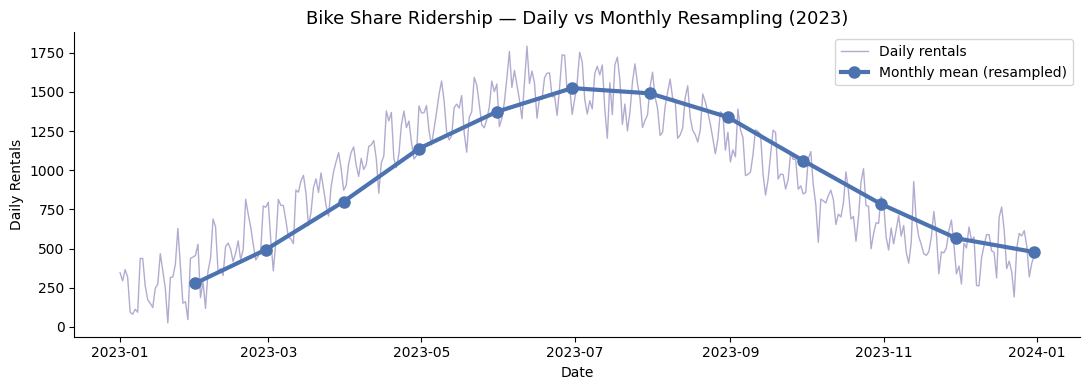

In [6]:
np.random.seed(7)

# ── Simulated daily bike share ridership (calibrated to the UCI Bike Sharing dataset) ──
dates  = pd.date_range("2023-01-01", "2023-12-31", freq="D")
n      = len(dates)
trend  = np.linspace(800, 1100, n)
season = 600 * np.sin(2 * np.pi * (np.arange(n) - 80) / 365)
weekly = 150 * np.sin(2 * np.pi * np.arange(n) / 7)
noise  = np.random.normal(0, 80, n)
counts = np.maximum(trend + season + weekly + noise, 0).astype(int)

ts         = pd.Series(counts, index=dates, name="rentals")
ts_monthly = ts.resample("ME").mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts.index, ts.values, color="#8172B2", linewidth=1,
        alpha=0.6, label="Daily rentals")
ax.plot(ts_monthly.index, ts_monthly.values, color="#4C72B0", linewidth=3,
        marker="o", markersize=8, label="Monthly mean (resampled)")
ax.set_title("Bike Share Ridership — Daily vs Monthly Resampling (2023)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Daily Rentals")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### Common datetime features for machine learning

| Feature | Pandas code | What it captures |
|---------|------------|-----------------|
| Year | `.dt.year` | Long-term trend |
| Month | `.dt.month` | Annual seasonality |
| Day of week | `.dt.dayofweek` | Weekly seasonality |
| Hour | `.dt.hour` | Intra-day patterns |
| Is weekend | `.dt.dayofweek >= 5` | Weekend vs weekday binary |
| Days since event | `(df["date"] - ref_date).dt.days` | Time since a reference point |
| Lag features | `.shift(n)` | Previous n-period value |
| Rolling mean | `.rolling(n).mean()` | Smoothed trend signal |

---
## Key takeaway

> **Dates are structured objects, not strings; parsing them correctly unlocks resampling, lag features, and seasonal components that are often the strongest predictors in time-series models.**

---
*Next up: Debugging & Reading Tracebacks — how to decode the error messages Python generates when a data science pipeline fails*